Pull synthetic hourly fridge (refrigerator) energy draw for a handful of
small multifamily (2-4 unit) NYC buildings from NREL/DOE's ResStock
End-Use Load Profiles dataset (public, no auth needed).

Dataset: resstock_amy2018_release_1.1 (2018 actual weather year), baseline
scenario (upgrade=0).

Output: one CSV with hourly fridge draw (W) for each sampled building,
plus a companion CSV of which building_ids were picked and why.


In [13]:
import io
import os
from datetime import datetime

import pandas as pd
import pyarrow.parquet as pq
import requests

import matplotlib.pyplot as plt
import pandas as pd

In [14]:
BASE = (
    "https://oedi-data-lake.s3.amazonaws.com/nrel-pds-building-stock/"
    "end-use-load-profiles-for-us-building-stock/2022/"
    "resstock_amy2018_release_1.1/"
)

# NYC's 5 boroughs = these county FIPS codes (used to find/verify the
# actual county identifiers ResStock uses in in.county, since the exact
# GISJOIN-style string format isn't reliably guessable across releases -
# see find_nyc_county_codes() below, which matches on these digits
# regardless of exact prefix/padding).
NYC_COUNTY_FIPS = {
    "005": "Bronx",
    "047": "Kings (Brooklyn)",
    "061": "New York (Manhattan)",
    "081": "Queens",
    "085": "Richmond (Staten Island)",
}
NY_STATE_FIPS = "36"

N_SAMPLES = 8  # "a handful, 5-10"
RNG_SEED = 42


def find_nyc_county_codes(meta: pd.DataFrame, county_col: str) -> dict:
    """
    Map each of ResStock's actual in.county values to a NYC borough name.

    Observed format in this dataset: 'G' + state FIPS (2) + '0' + county
    FIPS (3) + a trailing '0', e.g. 'G3600610' = state 36, county 061
    (Manhattan). Built directly rather than guessed, with a couple of
    fallback layouts in case a different release formats it differently.

    Returns {actual_county_value: borough_name}.
    """
    unique_vals = set(meta[county_col].dropna().unique())
    code_map = {}
    for fips, borough in NYC_COUNTY_FIPS.items():
        candidates = [
            f"G{NY_STATE_FIPS}0{fips}0",  # observed format, e.g. G3600610
            f"G{NY_STATE_FIPS}0{fips}",   # no trailing zero
            f"G{NY_STATE_FIPS}{fips}",    # no middle zero either
        ]
        for c in candidates:
            if c in unique_vals:
                code_map[c] = borough
                break
    return code_map


def fetch_parquet(url: str) -> pd.DataFrame:
    resp = requests.get(url, timeout=120)
    resp.raise_for_status()
    raw = resp.content
    try:
        return pd.read_parquet(io.BytesIO(raw))
    except Exception as e:
        # Known pyarrow/pandas version-mismatch issue: some ResStock parquet
        # files carry pandas extension-type metadata that an out-of-sync
        # pyarrow install can't resolve (e.g. "ArrowKeyError: No type
        # extension with name arrow.py_extension_type found"). Falling back
        # to a raw Arrow read (skipping pandas metadata reconstruction)
        # avoids the failing step.
        print(f"  pd.read_parquet failed ({e}); retrying with use_pandas_metadata=False")
        table = pq.read_table(io.BytesIO(raw), use_pandas_metadata=False)
        return table.to_pandas()


os.makedirs("outputs", exist_ok=True)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# ---- 1. Pull NY state metadata (building characteristics) ----
metadata_url = (
    BASE
    + "metadata_and_annual_results/by_state/state=NY/parquet/"
    "NY_baseline_metadata_and_annual_results.parquet"
)
print(f"Fetching metadata: {metadata_url}")
meta = fetch_parquet(metadata_url)

# Sanity check: confirm the columns we need exist; ResStock column
# names have shifted slightly across releases, so print + inspect if
# this KeyErrors for you.
county_col = "in.county"
btype_col = "in.geometry_building_type_recs"

print("Building type values available:", meta[btype_col].unique())

# building_id is sometimes the DataFrame index rather than a regular
# column, depending on how this parquet file was written.
if "building_id" not in meta.columns:
    print(f"'building_id' not in columns. Index name: {meta.index.name!r}")
    if meta.index.name and ("bldg" in str(meta.index.name).lower() or "building" in str(meta.index.name).lower()):
        meta = meta.reset_index()
        if "bldg_id" in meta.columns and "building_id" not in meta.columns:
            meta = meta.rename(columns={"bldg_id": "building_id"})
    else:
        id_like = [c for c in meta.columns if "bldg" in c.lower() or c.lower() == "id"]
        if id_like:
            meta = meta.rename(columns={id_like[0]: "building_id"})
        else:
            raise SystemExit(
                "Could not find a building_id column or index. "
                f"Columns available: {list(meta.columns)[:30]}"
            )

# ---- 2. Filter to NYC counties + small multifamily (2-4 units) ----
county_code_map = find_nyc_county_codes(meta, county_col)
print(f"Matched {len(county_code_map)} in.county values to NYC boroughs: {county_code_map}")

if not county_code_map:
    # Digit-matching found nothing either — dump what's actually in the
    # column so we can see the real format instead of guessing again.
    sample_vals = meta[county_col].dropna().unique()[:15]
    raise SystemExit(
        "Could not match any in.county value to a NYC borough. "
        f"Sample of actual in.county values in this file: {list(sample_vals)}\n"
        "Paste that list back so we can fix the matching logic."
    )

nyc_mask = meta[county_col].isin(county_code_map.keys())
# ResStock's enumeration for this category — verify against
# enumeration_dictionary.tsv if this filter comes back empty.
btype_mask = meta[btype_col].str.contains("2 - 4", case=False, na=False)

candidates = meta[nyc_mask & btype_mask]
print(f"Candidate buildings found: {len(candidates)}")

if len(candidates) == 0:
    raise SystemExit(
        "No matching buildings found — check county_col/btype_col "
        "values printed above and adjust the filters."
    )

sample = candidates.sample(n=min(N_SAMPLES, len(candidates)), random_state=RNG_SEED)
sample_ids = sample["building_id"].tolist()
print(f"Sampled building_ids: {sample_ids}")

# Save which buildings were picked, for reference/reproducibility
sample_cols = [c for c in ["building_id", county_col, btype_col] if c in sample.columns]
sample_log_path = f"outputs/resstock_nyc_sample_buildings_{timestamp}.csv"
sample[sample_cols].assign(
    borough=sample[county_col].map(county_code_map)
).to_csv(sample_log_path, index=False)
print(f"Saved sample building log to {sample_log_path}")

# ---- 3. Pull each building's individual timeseries, extract fridge ----
fridge_series = {}
for bid in sample_ids:
    ts_url = (
        BASE
        + f"timeseries_individual_buildings/by_state/upgrade=0/state=NY/{bid}-0.parquet"
    )
    print(f"Fetching timeseries for building {bid}: {ts_url}")
    df = fetch_parquet(ts_url)

    fridge_cols = [c for c in df.columns if "refrig" in c.lower()]
    if not fridge_cols:
        print(f"  WARNING: no refrigerator column found for building {bid}, skipping")
        continue
    fridge_col = fridge_cols[0]

    ts_col = "timestamp" if "timestamp" in df.columns else "Time"
    df[ts_col] = pd.to_datetime(df[ts_col])
    df = df.set_index(ts_col)

    # 15-min kWh -> hourly kWh (sum of 4 intervals) -> avg W over that hour
    hourly_kWh = df[fridge_col].resample("1h").sum()
    hourly_W = hourly_kWh * 1000.0

    fridge_series[f"building_{bid}"] = hourly_W

if not fridge_series:
    raise SystemExit("No fridge data retrieved for any sampled building.")

result = pd.DataFrame(fridge_series)
out_path = f"outputs/fridge_hourly_W_nyc_multifamily_{timestamp}.csv"
result.to_csv(out_path)
print(f"Saved hourly fridge draw (W) for {len(fridge_series)} buildings to {out_path}")

Fetching metadata: https://oedi-data-lake.s3.amazonaws.com/nrel-pds-building-stock/end-use-load-profiles-for-us-building-stock/2022/resstock_amy2018_release_1.1/metadata_and_annual_results/by_state/state=NY/parquet/NY_baseline_metadata_and_annual_results.parquet
Building type values available: ['Single-Family Detached' 'Multi-Family with 5+ Units'
 'Multi-Family with 2 - 4 Units' 'Mobile Home' 'Single-Family Attached']
'building_id' not in columns. Index name: 'bldg_id'
Matched 5 in.county values to NYC boroughs: {'G3600050': 'Bronx', 'G3600470': 'Kings (Brooklyn)', 'G3600610': 'New York (Manhattan)', 'G3600810': 'Queens', 'G3600850': 'Richmond (Staten Island)'}
Candidate buildings found: 3204
Sampled building_ids: [99702, 521669, 464850, 320071, 492434, 81946, 135796, 392164]
Saved sample building log to outputs/resstock_nyc_sample_buildings_20260723_173011.csv
Fetching timeseries for building 99702: https://oedi-data-lake.s3.amazonaws.com/nrel-pds-building-stock/end-use-load-profiles

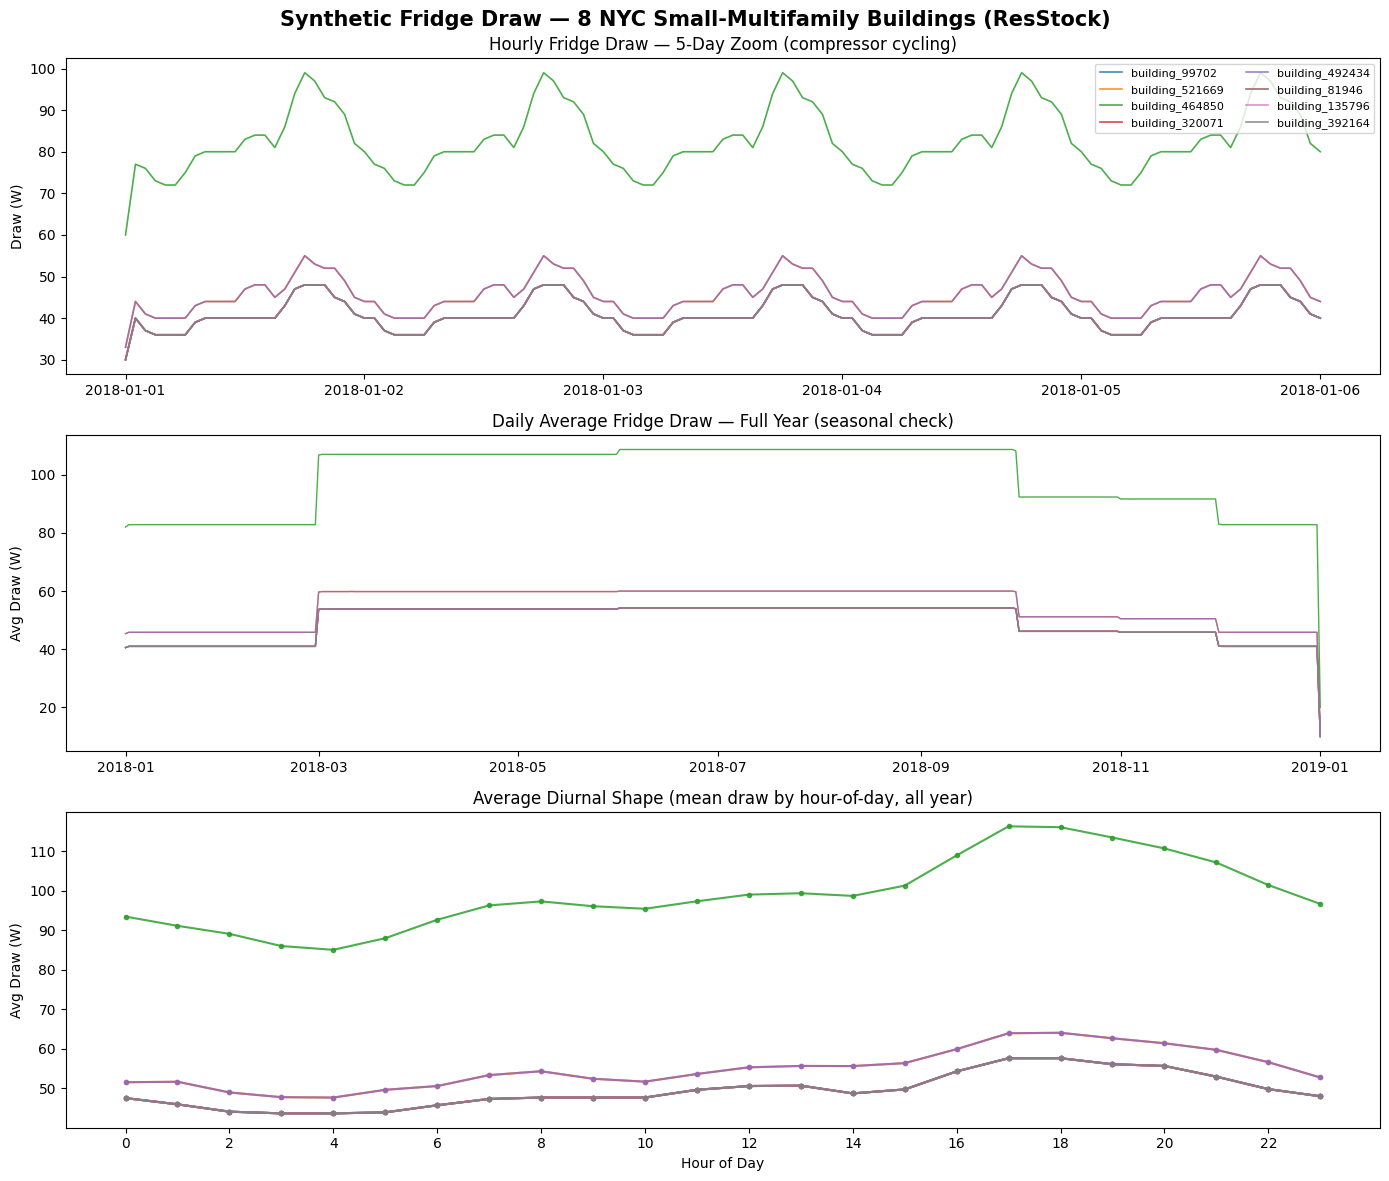

Saved fridge behavior plot to outputs/fridge_behavior_20260723_173011.png


In [15]:


def plot_fridge_behavior(result: pd.DataFrame, timestamp: str, zoom_days: int = 5) -> str:
    """
    Three-panel look at the sampled fridge profiles:
      1. A short zoomed window, showing the actual hour-to-hour cycling
         behavior (compressor on/off pattern) for each building.
      2. Daily average draw (W) across the full year per building, to
         check for any seasonal trend (kitchen ambient temp effects).
      3. Average diurnal shape (mean draw by hour-of-day), showing
         whether there's a consistent daily pattern (e.g. more door
         openings/higher draw during evening hours) across buildings.

    Saves the figure to outputs/fridge_behavior_<timestamp>.png and
    returns the path.
    """
    colors = plt.cm.tab10.colors
    n_buildings = result.shape[1]

    fig, axes = plt.subplots(3, 1, figsize=(14, 12))

    # ---- Panel 1: zoomed window, hour-to-hour cycling ----
    zoom_start = result.index[0]
    zoom_end = zoom_start + pd.Timedelta(days=zoom_days)
    window = result.loc[zoom_start:zoom_end]

    for i, col in enumerate(result.columns):
        axes[0].plot(window.index, window[col], color=colors[i % len(colors)],
                     linewidth=1.2, alpha=0.85, label=col)
    axes[0].set_ylabel("Draw (W)")
    axes[0].set_title(f"Hourly Fridge Draw — {zoom_days}-Day Zoom (compressor cycling)")
    axes[0].legend(loc="upper right", fontsize=8, ncol=2)

    # ---- Panel 2: daily average draw across the year ----
    daily_avg = result.resample("1D").mean()
    for i, col in enumerate(result.columns):
        axes[1].plot(daily_avg.index, daily_avg[col], color=colors[i % len(colors)],
                     linewidth=1, alpha=0.85, label=col)
    axes[1].set_ylabel("Avg Draw (W)")
    axes[1].set_title("Daily Average Fridge Draw — Full Year (seasonal check)")

    # ---- Panel 3: average diurnal shape (mean by hour-of-day) ----
    hourly_shape = result.groupby(result.index.hour).mean()
    for i, col in enumerate(result.columns):
        axes[2].plot(hourly_shape.index, hourly_shape[col], color=colors[i % len(colors)],
                     linewidth=1.5, marker="o", markersize=3, alpha=0.85, label=col)
    axes[2].set_xlabel("Hour of Day")
    axes[2].set_ylabel("Avg Draw (W)")
    axes[2].set_title("Average Diurnal Shape (mean draw by hour-of-day, all year)")
    axes[2].set_xticks(range(0, 24, 2))

    fig.suptitle(f"Synthetic Fridge Draw — {n_buildings} NYC Small-Multifamily Buildings (ResStock)",
                 fontsize=15, fontweight="bold")
    plt.tight_layout()

    out_path = f"outputs/fridge_behavior_{timestamp}.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    return out_path

plot_path = plot_fridge_behavior(result, timestamp)
print(f"Saved fridge behavior plot to {plot_path}")

Fetching metadata: https://oedi-data-lake.s3.amazonaws.com/nrel-pds-building-stock/end-use-load-profiles-for-us-building-stock/2022/resstock_amy2018_release_1.1/metadata_and_annual_results/by_state/state=NY/parquet/NY_baseline_metadata_and_annual_results.parquet
Candidate buildings found: 3204
Sampled 30 building_ids
Buildings with cooling data: 15 / 30 sampled

ResStock synthetic AC peak-kW distribution (DR window, DR season):
count    15.000000
mean      0.245333
std       0.166995
min       0.032000
25%       0.110000
50%       0.252000
75%       0.312000
max       0.560000
Name: peak_kW, dtype: float64

Real customer data load1_max_kW distribution:
n       60.000000
mean     0.715744
std      0.441644
min      0.000000
25%      0.461200
50%      0.589558
75%      1.013529
max      1.676217
dtype: float64

Saved comparison table to outputs/ac_real_vs_resstock_comparison_20260723_175817.csv


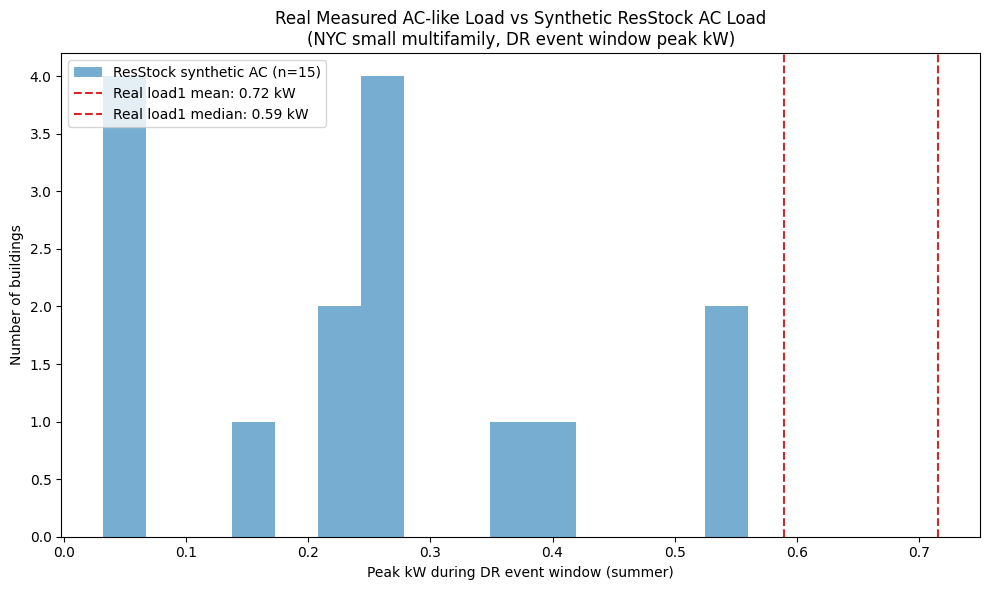

Saved comparison plot to outputs/ac_real_vs_resstock_20260723_175817.png


In [16]:
"""
Compare real, measured DR-event peak load draw (your customer_data_export
load1_max_kW / load2_max_kW) against ResStock's synthetic cooling
(air conditioning) load for NYC small multifamily buildings, using the
same "max kW during a DR event window" methodology on both sides so the
comparison is apples-to-apples.

CAVEAT: your real dataset's load_power_kwh_1/2/3 are just up to 3 numbered
circuits per household's metered system - not a labeled AC/fridge split.
load1 (present for ~all customers, largest average magnitude) is used
here as the best available proxy for "the AC-like flexible load," but
this is an assumption, not a confirmed appliance ID.

Requires: pandas, pyarrow, requests, matplotlib
"""



BASE = (
    "https://oedi-data-lake.s3.amazonaws.com/nrel-pds-building-stock/"
    "end-use-load-profiles-for-us-building-stock/2022/"
    "resstock_amy2018_release_1.1/"
)

NYC_COUNTY_FIPS = {
    "005": "Bronx",
    "047": "Kings (Brooklyn)",
    "061": "New York (Manhattan)",
    "081": "Queens",
    "085": "Richmond (Staten Island)",
}
NY_STATE_FIPS = "36"

# --- match your real dataset's most common DR event window ---
DR_WINDOW_START_HOUR = 16  # 16:00
DR_WINDOW_END_HOUR = 20    # 20:00, exclusive
DR_SEASON_MONTHS = range(5, 10)  # May-Sep, matching your model's DR season

N_SAMPLES = 30  # larger sample than the fridge pull, for a more stable distribution
RNG_SEED = 42

# --- your real customer_data_export summary stats (load1_max_kW), from
# your custome_data_analysis.ipynb aggregate describe() output. Update
# these if you re-run that notebook and get different numbers. ---
REAL_LOAD1_STATS = {
    "n": 60,
    "mean": 0.715744,
    "std": 0.441644,
    "min": 0.000000,
    "25%": 0.461200,
    "50%": 0.589558,
    "75%": 1.013529,
    "max": 1.676217,
}


def find_nyc_county_codes(meta: pd.DataFrame, county_col: str) -> dict:
    unique_vals = set(meta[county_col].dropna().unique())
    code_map = {}
    for fips, borough in NYC_COUNTY_FIPS.items():
        candidates = [
            f"G{NY_STATE_FIPS}0{fips}0",
            f"G{NY_STATE_FIPS}0{fips}",
            f"G{NY_STATE_FIPS}{fips}",
        ]
        for c in candidates:
            if c in unique_vals:
                code_map[c] = borough
                break
    return code_map


def fetch_parquet(url: str) -> pd.DataFrame:
    resp = requests.get(url, timeout=120)
    resp.raise_for_status()
    raw = resp.content
    try:
        return pd.read_parquet(io.BytesIO(raw))
    except Exception as e:
        print(f"  pd.read_parquet failed ({e}); retrying with use_pandas_metadata=False")
        table = pq.read_table(io.BytesIO(raw), use_pandas_metadata=False)
        return table.to_pandas()


def main():
    os.makedirs("outputs", exist_ok=True)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    # ---- 1. Metadata: NYC small multifamily buildings ----
    metadata_url = (
        BASE
        + "metadata_and_annual_results/by_state/state=NY/parquet/"
        "NY_baseline_metadata_and_annual_results.parquet"
    )
    print(f"Fetching metadata: {metadata_url}")
    meta = fetch_parquet(metadata_url)

    county_col = "in.county"
    btype_col = "in.geometry_building_type_recs"

    if "building_id" not in meta.columns:
        if meta.index.name and ("bldg" in str(meta.index.name).lower() or "building" in str(meta.index.name).lower()):
            meta = meta.reset_index()
            if "bldg_id" in meta.columns and "building_id" not in meta.columns:
                meta = meta.rename(columns={"bldg_id": "building_id"})
        else:
            raise SystemExit(f"Could not find building_id. Columns: {list(meta.columns)[:30]}")

    county_code_map = find_nyc_county_codes(meta, county_col)
    nyc_mask = meta[county_col].isin(county_code_map.keys())
    btype_mask = meta[btype_col].str.contains("2 - 4", case=False, na=False)
    candidates = meta[nyc_mask & btype_mask]
    print(f"Candidate buildings found: {len(candidates)}")

    if len(candidates) == 0:
        raise SystemExit("No matching buildings found.")

    sample = candidates.sample(n=min(N_SAMPLES, len(candidates)), random_state=RNG_SEED)
    sample_ids = sample["building_id"].tolist()
    print(f"Sampled {len(sample_ids)} building_ids")

    # ---- 2. Pull each building's cooling load, compute DR-window peak kW ----
    peak_kW_by_building = {}
    for bid in sample_ids:
        ts_url = BASE + f"timeseries_individual_buildings/by_state/upgrade=0/state=NY/{bid}-0.parquet"
        try:
            df = fetch_parquet(ts_url)
        except Exception as e:
            print(f"  Failed to fetch building {bid}: {e}")
            continue

        cooling_cols = [c for c in df.columns if "cooling" in c.lower() and "electric" in c.lower()]
        if not cooling_cols:
            print(f"  No cooling column for building {bid}, skipping (may not have AC)")
            continue
        cooling_col = cooling_cols[0]

        ts_col = "timestamp" if "timestamp" in df.columns else "Time"
        df[ts_col] = pd.to_datetime(df[ts_col])
        df = df.set_index(ts_col)

        # restrict to DR season + DR event window hours
        in_season = df.index.month.isin(DR_SEASON_MONTHS)
        in_window = (df.index.hour >= DR_WINDOW_START_HOUR) & (df.index.hour < DR_WINDOW_END_HOUR)
        window_df = df[in_season & in_window]

        if window_df.empty:
            continue

        # 15-min kWh -> kW (multiply by 4), take the peak over the DR season+window
        peak_kW = window_df[cooling_col].max() * 4
        if peak_kW > 0:
            peak_kW_by_building[bid] = peak_kW

    if not peak_kW_by_building:
        raise SystemExit("No buildings with usable cooling data found - try a larger N_SAMPLES.")

    peak_series = pd.Series(peak_kW_by_building, name="peak_kW")
    print(f"Buildings with cooling data: {len(peak_series)} / {len(sample_ids)} sampled")

    resstock_stats = peak_series.describe()
    print("\nResStock synthetic AC peak-kW distribution (DR window, DR season):")
    print(resstock_stats)

    print("\nReal customer data load1_max_kW distribution:")
    print(pd.Series(REAL_LOAD1_STATS))

    # ---- 3. Save comparison table + plot ----
    comparison = pd.DataFrame({
        "real_load1_max_kW": REAL_LOAD1_STATS,
        "resstock_ac_peak_kW": {
            "n": len(peak_series),
            "mean": resstock_stats["mean"],
            "std": resstock_stats["std"],
            "min": resstock_stats["min"],
            "25%": resstock_stats["25%"],
            "50%": resstock_stats["50%"],
            "75%": resstock_stats["75%"],
            "max": resstock_stats["max"],
        },
    })
    comp_path = f"outputs/ac_real_vs_resstock_comparison_{timestamp}.csv"
    comparison.to_csv(comp_path)
    print(f"\nSaved comparison table to {comp_path}")

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(peak_series, bins=15, alpha=0.6, color="tab:blue", label=f"ResStock synthetic AC (n={len(peak_series)})")
    for stat_name, val in [("mean", REAL_LOAD1_STATS["mean"]), ("median", REAL_LOAD1_STATS["50%"])]:
        ax.axvline(val, color="tab:red", linestyle="--", linewidth=1.5,
                   label=f"Real load1 {stat_name}: {val:.2f} kW")
    ax.set_xlabel("Peak kW during DR event window (summer)")
    ax.set_ylabel("Number of buildings")
    ax.set_title("Real Measured AC-like Load vs Synthetic ResStock AC Load\n(NYC small multifamily, DR event window peak kW)")
    ax.legend()
    plt.tight_layout()

    plot_path = f"outputs/ac_real_vs_resstock_{timestamp}.png"
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved comparison plot to {plot_path}")


if __name__ == "__main__":
    main()